In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import low_rank_approx
import sys
import os
# Add current directory to sys.path to import from utils
sys.path.append(os.getcwd())
from utils import low_rank_approx

Original Matrix A (2x3):
[[1. 2. 3.]
 [4. 5. 6.]]

Matrix U ((2, 2)):
[[-0.3863177  -0.92236578]
 [-0.92236578  0.3863177 ]]

Singular Values Σ (vector): [9.508032   0.77286964]
Σ as diagonal matrix:
[[9.508032   0.        ]
 [0.         0.77286964]]

Matrix V^T ((2, 3)):
[[-0.42866713 -0.56630692 -0.7039467 ]
 [ 0.80596391  0.11238241 -0.58119908]]

Reconstructed Matrix:
[[1. 2. 3.]
 [4. 5. 6.]]

Reconstruction Error (Frobenius norm): 2.75e-15
Verification: A = UΣV^T? True


**## Low Rank Approximation and Noise Reduction using SVD**

Original matrix (rank 5):
[[3.74540119 5.53354413 3.76289218 3.91031497 3.83935768]
 [5.53354413 0.58083612 9.18042999 4.52678627 4.23783219]
 [3.76289218 9.18042999 8.32442641 3.68547771 2.36984808]
 [3.91031497 4.52678627 3.68547771 4.31945019 3.28795492]
 [3.83935768 4.23783219 2.36984808 3.28795492 4.56069984]]

Noisy matrix (rank 5):
[[ 2.48645127  6.72898507  8.88186824  4.69878101  4.08379601]
 [ 4.50267281 -0.61967158 11.07530963  5.10885428  2.96671271]
 [ 1.71978779  8.85691922  7.2571288   3.67442199  1.91094717]
 [ 4.6890128   1.99654805  5.86946224  9.87607627  5.67523437]
 [ 4.27663431  6.00135427  0.35167739  0.12136649  6.10810068]]

Denoised matrix (k=3):
[[ 3.06502866  6.81006101  8.80194904  4.6960631   3.64191902]
 [ 3.21495254 -0.01798905 10.29818637  7.05017711  2.30031394]
 [ 1.91102644  8.46869231  7.73746676  2.64660139  2.64036952]
 [ 5.64812673  1.43239225  6.58993023  8.14309007  6.41630347]
 [ 3.2136517   6.54449167 -0.34655136  1.8388481   5.45999323]]

Fr

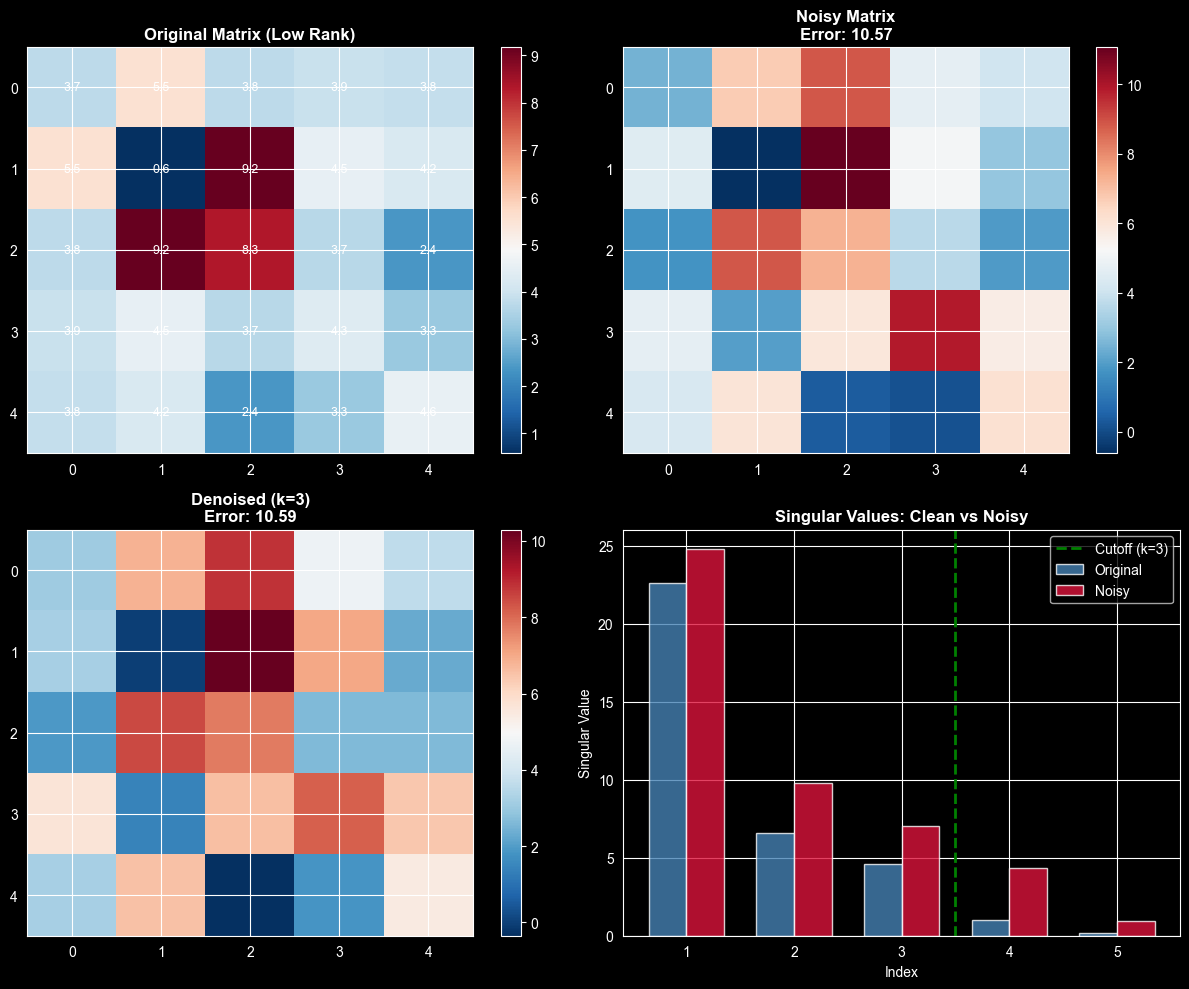


Denoising with different k values:
k   Error      Improvement 
------------------------------
1   10.8314    -2.47       %
2   10.5335    0.35        %
3   10.5885    -0.17       %
4   10.5708    -0.01       %
5   10.5701    0.00        %


In [2]:
# Generate random 5x5 matrix
A_clean = np.random.rand(5, 5) * 10
A_clean = (A_clean + A_clean.T) / 2  # Make it symmetric for structure

# Add noise
noise_level = 2.0
noise = np.random.randn(5, 5) * noise_level
A_noisy = A_clean + noise

print(f"Original matrix (rank {np.linalg.matrix_rank(A_clean)}):\n{A_clean}\n")
print(f"Noisy matrix (rank {np.linalg.matrix_rank(A_noisy)}):\n{A_noisy}\n")

# SVD of noisy matrix
U_n, s_n, Vt_n = np.linalg.svd(A_noisy)

# Determine optimal k (where singular values drop significantly)
# Using elbow method or fixed threshold
k_denoise = 3  # Keep top 3 components

A_denoised = low_rank_approx(U_n, s_n, Vt_n, k_denoise)

print(f"Denoised matrix (k={k_denoise}):\n{A_denoised}\n")

# Calculate errors
error_noisy = np.linalg.norm(A_clean - A_noisy, 'fro')
error_denoised = np.linalg.norm(A_clean - A_denoised, 'fro')
improvement = (error_noisy - error_denoised) / error_noisy * 100

print(f"Frobenius norm ||A_clean - A_noisy||:     {error_noisy:.4f}")
print(f"Frobenius norm ||A_clean - A_denoised||:  {error_denoised:.4f}")
print(f"Improvement: {improvement:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original
ax = axes[0, 0]
im = ax.imshow(A_clean, cmap='RdBu_r', aspect='auto')
ax.set_title('Original Matrix (Low Rank)', fontweight='bold')
plt.colorbar(im, ax=ax)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{A_clean[i, j]:.1f}', ha='center', va='center', fontsize=9)

# Noisy
ax = axes[0, 1]
im = ax.imshow(A_noisy, cmap='RdBu_r', aspect='auto')
ax.set_title(f'Noisy Matrix\nError: {error_noisy:.2f}', fontweight='bold')
plt.colorbar(im, ax=ax)

# Denoised
ax = axes[1, 0]
im = ax.imshow(A_denoised, cmap='RdBu_r', aspect='auto')
ax.set_title(f'Denoised (k={k_denoise})\nError: {error_denoised:.2f}', fontweight='bold')
plt.colorbar(im, ax=ax)

# Singular values comparison
ax = axes[1, 1]
x_pos = np.arange(1, 6)
width = 0.35

# We need SVD of clean matrix for comparison
U_c, s_c, Vt_c = np.linalg.svd(A_clean)

bars1 = ax.bar(x_pos - width/2, s_c, width, label='Original', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, s_n, width, label='Noisy', color='crimson', alpha=0.8)
ax.axvline(x=k_denoise+0.5, color='green', linestyle='--', linewidth=2, label=f'Cutoff (k={k_denoise})')
ax.set_xlabel('Index')
ax.set_ylabel('Singular Value')
ax.set_title('Singular Values: Clean vs Noisy', fontweight='bold')
ax.legend()
ax.set_xticks(x_pos)

plt.tight_layout()
plt.show()

# Test different k values for denoising
print(f"\nDenoising with different k values:")
print(f"{'k':<3} {'Error':<10} {'Improvement':<12}")
print("-" * 30)
for k_test in range(1, 6):
    A_test = low_rank_approx(U_n, s_n, Vt_n, k_test)
    err = np.linalg.norm(A_clean - A_test, 'fro')
    imp = (error_noisy - err) / error_noisy * 100
    print(f"{k_test:<3} {err:<10.4f} {imp:<12.2f}%")